In [1]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import numpy as np

In [2]:
Outbound = pd.read_csv('Out.csv')
Outbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1514430 entries, 0 to 1514429
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   ORDER NUMBER   1514430 non-null  object 
 1   INVOICEDATE    1514430 non-null  object 
 2   INV SALES-CTN  1514430 non-null  float64
 3   INV SALES-AMT  1514430 non-null  float64
 4   SKU No         1514430 non-null  int64  
 5   Desc           1514430 non-null  object 
 6   CUST_ID1       1514430 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 80.9+ MB


In [3]:
MBA = pd.read_csv('Out_cleaned.csv')
MBA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648364 entries, 0 to 648363
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   ORDER NUMBER  648364 non-null  object
 1   SKU No        648364 non-null  int64 
 2   Desc          648364 non-null  object
dtypes: int64(1), object(2)
memory usage: 14.8+ MB


In [4]:
MasterData = pd.read_csv('Master Data.csv')
MasterData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 694 entries, 0 to 693
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SKU No             694 non-null    int64 
 1   Desc               694 non-null    object
 2   conversion of ctn  694 non-null    int64 
 3   HI                 694 non-null    int64 
 4   TI                 694 non-null    int64 
 5   Ctn per Pallet     694 non-null    int64 
 6   Active             694 non-null    object
dtypes: int64(5), object(2)
memory usage: 38.1+ KB


In [5]:
Outbound['INVOICEDATE'] = pd.to_datetime(Outbound['INVOICEDATE'], format='%Y-%m-%d')
Outbound['Year Month'] = Outbound['INVOICEDATE'].dt.to_period('M').astype(str)
Outbound.head()

,ORDER NUMBER,INVOICEDATE,INV SALES-CTN,INV SALES-AMT,SKU No,Desc,CUST_ID1,Year Month
0,SSO0430648,2023-01-09,5.0,208.5,10000246,Item 10000246,Cust001260,2023-01
1,SSO0430648,2023-01-09,5.0,208.5,10000248,Item 10000248,Cust001260,2023-01
2,SSO0430648,2023-01-09,1.0,41.7,10000251,Item 10000251,Cust001260,2023-01
3,SSO0443645,2023-02-27,6.0,250.2,10000246,Item 10000246,Cust001260,2023-02
4,SSO0443645,2023-02-27,6.0,250.2,10000248,Item 10000248,Cust001260,2023-02


In [6]:
ABCAnalysis = Outbound[Outbound['INV SALES-AMT'] > 0]
ABCAnalysis = pd.pivot_table(ABCAnalysis, index=['SKU No', 'Desc'], values='INV SALES-AMT', aggfunc='sum', fill_value=0)
ABCAnalysis.reset_index(inplace=True)
ABCAnalysis.columns.name = None
ABCAnalysis.index.name = None
ABCAnalysis = ABCAnalysis.sort_values(by='INV SALES-AMT', ascending=False)
ABCAnalysis['Cum Amount'] = ABCAnalysis['INV SALES-AMT'].cumsum()
ABCAnalysis['Cum Contribution'] = (ABCAnalysis['Cum Amount'] / ABCAnalysis['INV SALES-AMT'].sum()) * 100
def map_abc(percentage):
    if percentage <= 70: 
        return 'A'
    elif percentage <= 90: 
        return 'B'
    else: 
        return 'C'
ABCAnalysis['ABC Class'] = ABCAnalysis['Cum Contribution'].apply(map_abc)
ABCAnalysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 107 to 303
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SKU No            365 non-null    int64  
 1   Desc              365 non-null    object 
 2   INV SALES-AMT     365 non-null    float64
 3   Cum Amount        365 non-null    float64
 4   Cum Contribution  365 non-null    float64
 5   ABC Class         365 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 20.0+ KB


In [7]:
XYZAnalysis = Outbound[Outbound['INV SALES-AMT'] > 0]
XYZAnalysis = pd.pivot_table(XYZAnalysis, index=['SKU No', 'Desc'], columns='Year Month', values='INV SALES-AMT', aggfunc='sum', fill_value=0)
XYZAnalysis['Std Dev'] = XYZAnalysis.std(axis=1)
XYZAnalysis['Avg Demand'] = XYZAnalysis.mean(axis=1)
XYZAnalysis['Coefficient of Variation'] = XYZAnalysis['Std Dev'] / XYZAnalysis['Avg Demand']
def map_xyz(cv):
    if cv <= 0.5: 
        return 'X'
    elif cv <= 1.0: 
        return 'Y' 
    else: 
        return 'Z'
XYZAnalysis['XYZ Class'] = XYZAnalysis['Coefficient of Variation'].apply(map_xyz)
XYZAnalysis.reset_index(inplace=True)
XYZAnalysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SKU No                    365 non-null    int64  
 1   Desc                      365 non-null    object 
 2   2023-01                   365 non-null    float64
 3   2023-02                   365 non-null    float64
 4   2023-03                   365 non-null    float64
 5   2023-04                   365 non-null    float64
 6   2023-05                   365 non-null    float64
 7   2023-06                   365 non-null    float64
 8   2023-07                   365 non-null    float64
 9   2023-08                   365 non-null    float64
 10  2023-09                   365 non-null    float64
 11  2023-10                   365 non-null    float64
 12  2023-11                   365 non-null    float64
 13  2023-12                   365 non-null    float64
 14  2024-01   

In [8]:
ABCvsXYZ = ABCAnalysis.merge(XYZAnalysis, on=['SKU No', 'Desc'], how='left')
ABCvsXYZ.reset_index(drop=True, inplace=True)
ABCvsXYZ = ABCvsXYZ[['SKU No', 'Desc', 'ABC Class', 'XYZ Class']]
ABCvsXYZ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   SKU No     365 non-null    int64 
 1   Desc       365 non-null    object
 2   ABC Class  365 non-null    object
 3   XYZ Class  365 non-null    object
dtypes: int64(1), object(3)
memory usage: 11.5+ KB


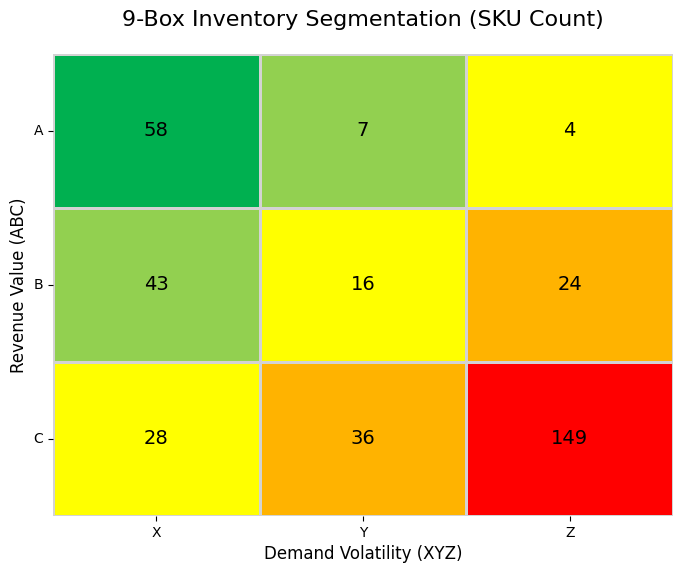

In [9]:
ABCvsXYZ['9_Box'] = ABCvsXYZ['ABC Class'] + ABCvsXYZ['XYZ Class']

NineBox = ABCvsXYZ['9_Box'].value_counts().sort_index()
NineBox = pd.crosstab(ABCvsXYZ['ABC Class'], ABCvsXYZ['XYZ Class'])

NineBox = NineBox.reindex(index=['A', 'B', 'C'], columns=['X', 'Y', 'Z'])

color_data = [[4, 3, 2], 
              [3, 2, 1], 
              [2, 1, 0]]

custom_cmap = ListedColormap(['#FF0000', '#FFB300', '#FFFF00', '#92D050', '#00B050'])

plt.figure(figsize=(8, 6))

sns.heatmap(color_data, 
            annot=NineBox.values,
            fmt='d', 
            cmap=custom_cmap, 
            linewidths=1, 
            linecolor='lightgrey',
            cbar=False,
            xticklabels=['X', 'Y', 'Z'], 
            yticklabels=['A', 'B', 'C'],
            annot_kws={"size": 14, "color": "black"})

plt.title('9-Box Inventory Segmentation (SKU Count)', fontsize=16, pad=20)
plt.xlabel('Demand Volatility (XYZ)', fontsize=12)
plt.ylabel('Revenue Value (ABC)', fontsize=12)
plt.yticks(rotation=0)

plt.show()

- Observation: The largest segment by far is "CZ" with 149 items. This represents nearly 40% of the total SKU count that is both low-value and unpredictable. There are 69 "A-class" items are the high-revenue drivers of the business. 58 of them (AX items) are the the revenue generators of the business, as they are the most stable and predictable items in terms of demand.
- Bottleneck: The 28 "CX" items are low value but high volatility, if these items scattered, they would create "traffic jams" in the aisles and affecting picker to reach the high-value AX items.
- Insight: The high number of CZ items (149) suggest that the current storage capacity bottleneck isn't caused by "too much business", but by "too much slow-moving variety".
- Suggestion: The 101 items (AX and BX) need to be relocated to the most accessible racks to the loading docks. "AZ", "BY" and "CX" should be in Zone 2, while "BZ", "CY", and "CZ" should be in Zone 3. This ABC-XYZ Analysis should be audited quarterly to ensure pick faces align with current demand patterns.

In [10]:
basket_data = MBA.pivot_table(index='ORDER NUMBER', columns='SKU No', aggfunc='size', fill_value=0)
basket_data.reset_index(inplace=True)
basket_data.columns.name = None
basket_data.index.name = None
basket_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122017 entries, 0 to 122016
Columns: 195 entries, ORDER NUMBER to 10000433
dtypes: int64(194), object(1)
memory usage: 181.5+ MB


In [11]:
basket_data = basket_data.apply(pd.to_numeric, errors='coerce')

basket_data.shape
basket_data.sum(axis=1).describe()

count    122017.000000
mean          5.313719
std           4.392254
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          72.000000
dtype: float64

In [12]:
basket_size = basket_data.sum(axis=1)
basket_data_filtered = basket_data[basket_size <= 30]

basket_data_filtered.shape
basket_data_filtered.sum(axis=1).describe()

count    121874.000000
mean          5.279157
std           4.273611
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          30.000000
dtype: float64

In [13]:
basket_data_filtered = basket_data_filtered.fillna(False)

frequent_itemsets = apriori(
    basket_data_filtered,
    min_support=0.03,
    use_colnames=True,
    max_len=2
)
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.2
)

print(rules.shape)
print(rules['antecedents'].apply(len).value_counts())
print(rules['consequents'].apply(len).value_counts())

C:\Users\peiyi\AppData\Local\Temp\ipykernel_20864\3899690598.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  basket_data_filtered = basket_data_filtered.fillna(False)
C:\Users\peiyi\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


(136, 14)
antecedents
1    136
Name: count, dtype: int64
consequents
1    136
Name: count, dtype: int64


In [14]:
rules['antecedents'] = rules['antecedents'].apply(lambda x: list(x)[0])
rules['consequents'] = rules['consequents'].apply(lambda x: list(x)[0])

mba_pairs = rules.rename(columns={
    'antecedents': 'item_A',
    'consequents': 'item_B'
})
mba_pairs.head()

,item_A,item_B,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,10000001,10000003,0.126188,0.056649,0.039172,0.310423,5.479799,1.0,0.032023,1.368015,0.935569,0.272660,0.269014,0.500953
1,10000003,10000001,0.056649,0.126188,0.039172,0.691483,5.479799,1.0,0.032023,2.832301,0.866603,0.272660,0.646930,0.500953
2,10000001,10000034,0.126188,0.159427,0.060628,0.480460,3.013671,1.0,0.040510,1.617919,0.764671,0.269475,0.381922,0.430374
3,10000034,10000001,0.159427,0.126188,0.060628,0.380288,3.013671,1.0,0.040510,1.410030,0.794909,0.269475,0.290795,0.430374
4,10000040,10000001,0.098914,0.126188,0.032739,0.330983,2.622942,1.0,0.020257,1.306114,0.686670,0.170193,0.234370,0.295214


In [15]:
mba_pairs = mba_pairs.merge(ABCvsXYZ, left_on='item_A', right_on='SKU No', how='left')
mba_pairs = mba_pairs.rename(columns={'ABC Class':'item_A_ABC', 'XYZ Class':'item_A_XYZ'})
mba_pairs = mba_pairs.drop(columns=['SKU No', 'Desc', '9_Box'])
mba_pairs = mba_pairs.merge(ABCvsXYZ, left_on='item_B', right_on='SKU No', how='left')
mba_pairs = mba_pairs.rename(columns={'ABC Class':'item_B_ABC', 'XYZ Class':'item_B_XYZ'})
mba_pairs = mba_pairs.drop(columns=['SKU No', 'Desc', '9_Box', 'antecedent support',	'consequent support', 'representativity', 'leverage', 
                                    'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski'])
mba_pairs.head()

,item_A,item_B,support,confidence,lift,item_A_ABC,item_A_XYZ,item_B_ABC,item_B_XYZ
0,10000001,10000003,0.039172,0.310423,5.479799,A,X,B,X
1,10000003,10000001,0.039172,0.691483,5.479799,B,X,A,X
2,10000001,10000034,0.060628,0.480460,3.013671,A,X,A,X
3,10000034,10000001,0.060628,0.380288,3.013671,A,X,A,X
4,10000040,10000001,0.032739,0.330983,2.622942,A,X,A,X


In [16]:
mba_use = mba_pairs[
    (mba_pairs['lift'] >= 1.2) &
    (mba_pairs['confidence'] >= 0.5) &
    (mba_pairs['support'] >= 0.01)
].copy()
mba_use.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 1 to 135
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   item_A      44 non-null     int64  
 1   item_B      44 non-null     int64  
 2   support     44 non-null     float64
 3   confidence  44 non-null     float64
 4   lift        44 non-null     float64
 5   item_A_ABC  44 non-null     object 
 6   item_A_XYZ  44 non-null     object 
 7   item_B_ABC  44 non-null     object 
 8   item_B_XYZ  44 non-null     object 
dtypes: float64(3), int64(2), object(4)
memory usage: 3.4+ KB


In [17]:
mba_use['pair_key'] = mba_use.apply(
    lambda r: tuple(sorted([r['item_A'], r['item_B']])),
    axis=1
)
mba_use = (
    mba_use
    .sort_values(['pair_key','lift','confidence'], ascending=[True, False, False])
    .drop_duplicates('pair_key')
)
mba_use.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 1 to 134
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   item_A      27 non-null     int64  
 1   item_B      27 non-null     int64  
 2   support     27 non-null     float64
 3   confidence  27 non-null     float64
 4   lift        27 non-null     float64
 5   item_A_ABC  27 non-null     object 
 6   item_A_XYZ  27 non-null     object 
 7   item_B_ABC  27 non-null     object 
 8   item_B_XYZ  27 non-null     object 
 9   pair_key    27 non-null     object 
dtypes: float64(3), int64(2), object(5)
memory usage: 2.3+ KB


In [18]:
abc_weight = {'A':3, 'B':2, 'C':1}

mba_use['priority_score'] = (
    mba_use['lift'] *
    mba_use['confidence'] *
    mba_use['support'] *
    mba_use['item_A_ABC'].map(abc_weight) *
    mba_use['item_B_ABC'].map(abc_weight)
)
mba_use.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 1 to 134
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_A          27 non-null     int64  
 1   item_B          27 non-null     int64  
 2   support         27 non-null     float64
 3   confidence      27 non-null     float64
 4   lift            27 non-null     float64
 5   item_A_ABC      27 non-null     object 
 6   item_A_XYZ      27 non-null     object 
 7   item_B_ABC      27 non-null     object 
 8   item_B_XYZ      27 non-null     object 
 9   pair_key        27 non-null     object 
 10  priority_score  27 non-null     float64
dtypes: float64(4), int64(2), object(5)
memory usage: 2.5+ KB


In [19]:
def classify(row): 
    if row['item_A_ABC']=='A' and row['item_B_ABC']=='A' and row['item_A_XYZ']=='X' and row['item_B_XYZ']=='X': 
        return 'Co-locate (high priority)' 
    if 'Z' in (row['item_A_XYZ'], row['item_B_XYZ']): 
        return 'Unstable demand (flexible placement)' 
    if row['item_A_ABC']=='C' and row['item_B_ABC']=='C': 
        return 'Promotion/bundle only' 
    return 'Standard adjacency' 
mba_use['action'] = mba_use.apply(classify, axis=1) 
mba_use.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 1 to 134
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_A          27 non-null     int64  
 1   item_B          27 non-null     int64  
 2   support         27 non-null     float64
 3   confidence      27 non-null     float64
 4   lift            27 non-null     float64
 5   item_A_ABC      27 non-null     object 
 6   item_A_XYZ      27 non-null     object 
 7   item_B_ABC      27 non-null     object 
 8   item_B_XYZ      27 non-null     object 
 9   pair_key        27 non-null     object 
 10  priority_score  27 non-null     float64
 11  action          27 non-null     object 
dtypes: float64(4), int64(2), object(6)
memory usage: 2.7+ KB


In [20]:
top_pairs = (
    mba_use
    .sort_values('priority_score', ascending=False)
    .head(20)
)
top_pairs[['item_A','item_B','lift','confidence','item_A_ABC','item_B_ABC']]
top_pairs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 129 to 122
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_A          20 non-null     int64  
 1   item_B          20 non-null     int64  
 2   support         20 non-null     float64
 3   confidence      20 non-null     float64
 4   lift            20 non-null     float64
 5   item_A_ABC      20 non-null     object 
 6   item_A_XYZ      20 non-null     object 
 7   item_B_ABC      20 non-null     object 
 8   item_B_XYZ      20 non-null     object 
 9   pair_key        20 non-null     object 
 10  priority_score  20 non-null     float64
 11  action          20 non-null     object 
dtypes: float64(4), int64(2), object(6)
memory usage: 2.0+ KB


In [21]:
Outbound = Outbound[Outbound['INV SALES-AMT'] > 0].copy().reset_index(drop=True)
Outbound = Outbound.merge(MasterData, on=['SKU No', 'Desc'], how='left')
Outbound.reset_index(drop=True, inplace=True)
Outbound = Outbound[Outbound['Active'] == 'Active'].copy().reset_index(drop=True)
Outbound['pallets'] = np.floor(Outbound['INV SALES-CTN'] / Outbound['Ctn per Pallet'])
Outbound['cartons'] = Outbound['INV SALES-CTN'] - Outbound['pallets'] * Outbound['Ctn per Pallet']
Outbound.head()

,ORDER NUMBER,INVOICEDATE,INV SALES-CTN,INV SALES-AMT,SKU No,Desc,CUST_ID1,Year Month,conversion of ctn,HI,TI,Ctn per Pallet,Active,pallets,cartons
0,SSO0430648,2023-01-09,1.0,41.70,10000251,Item 10000251,Cust001260,2023-01,12,6,5,30,Active,0.0,1.0
1,SSO0443645,2023-02-27,4.0,166.80,10000251,Item 10000251,Cust001260,2023-02,12,6,5,30,Active,0.0,4.0
2,SSO0445209,2023-03-01,1.0,58.56,10000067,Item 10000067,Cust002165,2023-03,30,6,6,36,Active,0.0,1.0
3,SSO0445209,2023-03-01,1.0,58.56,10000076,Item 10000076,Cust002165,2023-03,12,5,12,60,Active,0.0,1.0
4,SSO0445209,2023-03-01,1.0,98.16,10000121,Item 10000121,Cust002165,2023-03,12,4,8,32,Active,0.0,1.0


In [22]:
DailyRequirement = pd.pivot_table(Outbound, index=['INVOICEDATE', 'SKU No', 'Desc', 'Ctn per Pallet'], values='cartons', aggfunc='sum', fill_value=0)
DailyRequirement.reset_index(inplace=True)
DailyRequirement.columns.name = None
DailyRequirement.index.name = None
DailyRequirement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37980 entries, 0 to 37979
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   INVOICEDATE     37980 non-null  datetime64[ns]
 1   SKU No          37980 non-null  int64         
 2   Desc            37980 non-null  object        
 3   Ctn per Pallet  37980 non-null  int64         
 4   cartons         37980 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 1.4+ MB


In [23]:
DailyRequirement = DailyRequirement.merge(ABCvsXYZ, on=['SKU No', 'Desc'], how='left')
DailyRequirement.reset_index(drop=True, inplace=True)
DailyRequirement = DailyRequirement.drop(columns=['9_Box'])
DailyRequirement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37980 entries, 0 to 37979
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   INVOICEDATE     37980 non-null  datetime64[ns]
 1   SKU No          37980 non-null  int64         
 2   Desc            37980 non-null  object        
 3   Ctn per Pallet  37980 non-null  int64         
 4   cartons         37980 non-null  float64       
 5   ABC Class       37980 non-null  object        
 6   XYZ Class       37980 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 2.0+ MB


In [24]:
def get_tiered_quantile(group):
    xyz = group['XYZ Class'].iloc[0]
    if xyz == 'X':
        q = 0.99
    elif xyz == 'Y':
        q = 0.9
    else: 
        q = 0.9
    return group['cartons'].quantile(q)

DailyRequirementTiered = (DailyRequirement.groupby(['SKU No', 'Desc', 'Ctn per Pallet', 'ABC Class', 'XYZ Class'])['cartons']
    .apply(lambda x: get_tiered_quantile(DailyRequirement[DailyRequirement.index.isin(x.index)]))
    .reset_index(name='Cartons per day (Tiered)'))

DailyRequirementTiered['Pallets per day at 90%'] = np.ceil(
    DailyRequirementTiered['Cartons per day (Tiered)'] / DailyRequirementTiered['Ctn per Pallet']
)

def classify(x):
    if 2 < x:
        return 2
    else:
        return x
DailyRequirementTiered['Pick Faces (pallets)'] = DailyRequirementTiered['Pallets per day at 90%'].apply(classify)

DailyRequirementTiered['Pick Faces (pallets)'] = np.ceil(DailyRequirementTiered['Pallets per day at 90%'] / 2)

total_pallets = DailyRequirementTiered['Pick Faces (pallets)'].sum()
print(f"Total Pick Faces required: {total_pallets}")

Total Pick Faces required: 661.0


In [25]:
DailyRequirementTiered['Cartons at Pick Faces'] = DailyRequirementTiered['Pick Faces (pallets)'] * 2 * DailyRequirementTiered['Ctn per Pallet']
DailyRequirement = DailyRequirement.merge(DailyRequirementTiered, on=['SKU No', 'Desc', 'Ctn per Pallet', 'ABC Class', 'XYZ Class'], how='left')
DailyRequirement['differences'] = DailyRequirement['Cartons at Pick Faces'] - DailyRequirement['cartons']
DailyRequirement['shortfall'] = DailyRequirement['differences'].clip(upper=0)
DailyRequirement.head()

,INVOICEDATE,SKU No,Desc,Ctn per Pallet,cartons,ABC Class,XYZ Class,Cartons per day (Tiered),Pallets per day at 90%,Pick Faces (pallets),Cartons at Pick Faces,differences,shortfall
0,2023-01-03,10000001,Item 10000001,64,2478.0,A,X,1322.01,21.0,11.0,1408.0,-1070.0,-1070.0
1,2023-01-03,10000003,Item 10000003,60,816.0,B,X,733.24,13.0,7.0,840.0,24.0,0.0
2,2023-01-03,10000009,Item 10000009,20,8.0,C,Z,24.00,2.0,1.0,40.0,32.0,0.0
3,2023-01-03,10000010,Item 10000010,60,11.0,C,Z,22.60,1.0,1.0,120.0,109.0,0.0
4,2023-01-03,10000013,Item 10000013,72,174.0,C,Z,91.60,2.0,1.0,144.0,-30.0,-30.0


In [26]:
ShortFall = DailyRequirement['shortfall'].sum()
TotalVolume = DailyRequirement['cartons'].sum()
RiskPercentage = (abs(ShortFall.sum()) / TotalVolume) * 100
print(f"Risk Percentage: {RiskPercentage:.2f}%")

Risk Percentage: 2.45%


- Observation: A total of 720 pick faces are available after implementing double-deep racking, while the current requirement is 661 pick faces, indicating sufficient storage capacity under planned conditions.
- Bottleneck: There is a 2.45% probability that pick faces will be insufficient to meet daily demand, resulting in mid-picking replenishment and potential disruption to picking operations.
- Insight: The pick face design is based on a tiered service level creates a controlled trade-off between space efficiency and operational risk, where lower-priority items are more likely to trigger replenishment.
- Suggestion: The pick face allocation needs to be reviewed quarterly to reflect demand variability. 

In [27]:
with pd.ExcelWriter('Pick Faces_Output.xlsx') as writer:
    top_pairs.to_excel(writer, sheet_name='top_pairs', index=False)
    DailyRequirementTiered.to_excel(writer, sheet_name='Pick Faces', index=False)